# 3 - Preprocessing & Exploratory Data Analysis

Now that we have the text out of our document sample, we can start to break down the text further with preprocessing, and start to explore the variations and patterns in our dataset.

There are a number of standard checks and explorations we want to look at as part of a natural language processing project, including distributions of length of documents, sentences, special characters. We also want to make some comparisons against metadata characteristics, to be aware of any trends or correlations that we should be aware of in our corpus.

At the end of the EDA process, we want to have a better understanding of the contents and patterns in the corpus. If we go into the modeling process blind to the content of our dataset, we are going to take ineffective modeling or statistical approaches. Or, we may inadvertently make choices or mistakes that could have been avoided if we better understood the characteristics and limitations of our corpus.


In [12]:
import os
import spacy
import pickle
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from typing import List, Set, Dict, Tuple
from dotenv import load_dotenv

<br/>

Set home directory - we suggest making this the data folder in the repo:

In [13]:
load_dotenv()
HOME_DIRECTORY = os.getenv("HOME_DIRECTORY")
datum = os.path.join(HOME_DIRECTORY, "data")
data_text = os.path.join(datum, "data_text")

data_pickle = os.path.join(datum, "data_pickles")

# create path if not exists
Path(data_pickle).mkdir(parents=True, exist_ok=True)

print(f'HOME_DIRECTORY : {HOME_DIRECTORY}')
print(f"DATA TEXT: {data_text}")
print(f"DATA TEXT: {data_pickle}")

HOME_DIRECTORY : /Users/affanali/Downloads/Middlesex/CST4012-MachineLearning/TC2R-CodeCompanion
DATA TEXT: /Users/affanali/Downloads/Middlesex/CST4012-MachineLearning/TC2R-CodeCompanion/data/data_text
DATA TEXT: /Users/affanali/Downloads/Middlesex/CST4012-MachineLearning/TC2R-CodeCompanion/data/data_pickles


<br/><br/><br/>

## Segment Sentences

Let's first ingest our OCR extraction results, and segment the text data into individual sentences.

In [7]:
def read_text_files(folder_path: str):
    """
    Read text from a folder of .txt files.

    Parameters:
    - folder_path (str): Path to the folder containing .txt files.

    Returns:
    - texts (list): List of strings, where each string is the content of a text file.
    """
    texts = []
    files = []
    for filename in os.listdir(folder_path):
        if filename.endswith(".txt"):
            file_path = os.path.join(folder_path, filename)
            with open(file_path, 'r', encoding='utf-8') as file:
                text = file.read()
                texts.append(text)
                files.append(filename)

    return texts, files

def process_texts_to_dataframe(texts: List, filenames: List):
    """
    Tokenize sentences in a list of texts and save the results in a Pandas DataFrame.

    Parameters:
    - texts (list): List of texts to be processed.
    - filenames (list): List of corresponding filenames.

    Returns:
    - df (DataFrame): Pandas DataFrame containing columns: 'filename', 'sentence_index', 'sentence_text'.
    """
    nlp = spacy.load('en_core_web_sm', exclude=["parser"])
    config = {"punct_chars": ['\n\n', '.', '?', '!']}
    nlp.add_pipe("sentencizer", config=config)
    
    data = {'filename': [], 'sentence_index': [], 'sentence_text': []}

    for filename, text in zip(filenames, texts):
        for i, sentence in enumerate(nlp(text).sents):
            data['filename'].append(filename)
            data['sentence_index'].append(i)
            data['sentence_text'].append(sentence.text)

    df = pd.DataFrame(data)
    return df


In [8]:
texts, filenames = read_text_files(data_text)
sentences_df = process_texts_to_dataframe(texts, filenames)
sentences_df.head()

,filename,sentence_index,sentence_text
0,00002MGK.pdf.txt,0,Modification Summary Report\n\n
1,00002MGK.pdf.txt,1,Conteact (PO) Number: 1406\nModification Revis...
2,00002MGK.pdf.txt,2,Specification Number: 3858\n\n
3,00002MGK.pdf.txt,3,Name of Contractor: GLOBETROTTERS ENGINEERING ...
4,00002MGK.pdf.txt,4,City Department: DEPARTMENT OF CONSTRUCTION AN...


<br/><br/>

Given that the processing can take a while, we will save the results to a pickle file so that we don't have to re-run this code again unnecessarily:

In [14]:
#sentences_df.to_pickle(os.path.join(data_pickle, 'corpus_sentences.pkl'))

Once it's saved, we can load our results back in quickly rather than re-running the code.

*Note*: As with all large files, you may also pull this pickled file from the Google drive.

In [15]:
# Once saved, read the DataFrame from the Pickle file
sentences_df = pd.read_pickle(os.path.join(data_pickle, 'corpus_sentences.pkl'))

# Display the loaded DataFrame
sentences_df

,filename,sentence_index,sentence_text
0,00002MGK.pdf.txt,0,Modification Summary Report\n\n
1,00002MGK.pdf.txt,1,Conteact (PO) Number: 1406\nModification Revis...
2,00002MGK.pdf.txt,2,Specification Number: 3858\n\n
3,00002MGK.pdf.txt,3,Name of Contractor: GLOBETROTTERS ENGINEERING ...
4,00002MGK.pdf.txt,4,City Department: DEPARTMENT OF CONSTRUCTION AN...
...,...,...,...
772796,00002QKJ.pdf.txt,50,Het 7\n\n‘
772797,00002QKJ.pdf.txt,51,Subscribed and swom to before me thus 2/ 5+\n\n
772798,00002QKJ.pdf.txt,52,"Day of Decemuhers 2006\n_ “opriciat seat""\nNot..."
772799,00002QKJ.pdf.txt,53,"ay Soman Eres No 8 2008,\n\n‘"


<br/><br/>

## Exploratory Data Analysis

Let's start walking through some standard checks as part of our exploratory data analysis. It's helpful to explore the corpus at the document level and sentence level.

<br/>

### Document Distributions

One initial set of checks is to simply look at the overall distribution of document length across the corpus, as well as the distribution of the sentence lengths.

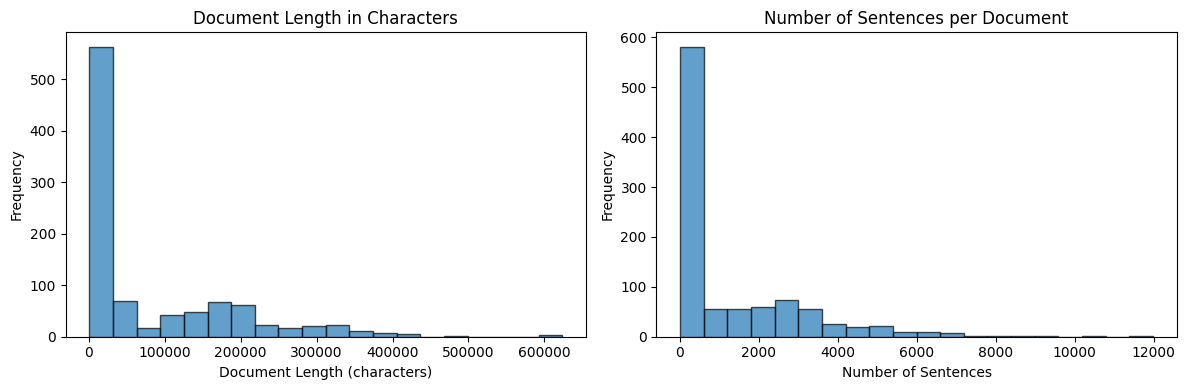

In [16]:
def plot_document_length_histograms(texts: List, dataframe):
    """
    Plot side-by-side histograms of document lengths in characters and sentences per document.

    Parameters:
    - texts (list): List of documents (strings).
    - dataframe (DataFrame): Pandas DataFrame with columns 'filename' and 'sentence_text'.

    Returns:
    None
    """
    # Calculate document lengths in characters and sentences
    dataframe['document_length_chars'] = dataframe['sentence_text'].apply(lambda x: len(x))
    dataframe['sentence_count'] = dataframe['sentence_text'].apply(lambda x: len(x.split('.')))

    # Group by filename and aggregate document lengths
    grouped_data = dataframe.groupby('filename').agg({
        'document_length_chars': 'sum',
        'sentence_count': 'sum'
    }).reset_index()

    # Create subplots
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Plot histogram of document lengths in characters
    axes[0].hist(grouped_data['document_length_chars'], bins=20, edgecolor='black', alpha=0.7)
    axes[0].set_title('Document Length in Characters')
    axes[0].set_xlabel('Document Length (characters)')
    axes[0].set_ylabel('Frequency')

    # Plot histogram of document lengths in sentences
    axes[1].hist(grouped_data['sentence_count'], bins=20, edgecolor='black', alpha=0.7)
    axes[1].set_title('Number of Sentences per Document')
    axes[1].set_xlabel('Number of Sentences')
    axes[1].set_ylabel('Frequency')

    # Adjust layout
    plt.tight_layout()

    # Show the plot
    plt.show()
    return grouped_data

corpus_lengths = plot_document_length_histograms(texts, sentences_df)

<br/>
As we explore a new corpus, we want to make sure our data is making logical and business sense. Why would there be a document with zero sentences or a character length of zero? What is going on with the outlier at 600,000 characters?

In [17]:
corpus_lengths[['filename', 'document_length_chars']].sort_values('document_length_chars')

,filename,document_length_chars
705,{3648F9D4-6EBB-4789-A865-A236D2FB3239}.pdf.txt,854
860,{AA465F2E-E554-49D6-8116-948C8B5AE456}.pdf.txt,1018
709,{3705C921-2477-425E-8EA5-C4977C4F5885}.pdf.txt,1049
761,{553A1CA2-36AE-4D2B-8BC4-C674C4ADA13D}.pdf.txt,1089
817,{88B57A0D-4478-418A-9481-A2DDB07E8355}.pdf.txt,1092
...,...,...
878,{B588AD29-48A9-4A2C-AA83-2BD7584F027A}.pdf.txt,473172
148,000027KN.pdf.txt,487013
814,{86339CAD-3FFE-4D78-B5D0-F9BB8D2B3DE4}.pdf.txt,595226
912,{CAE88AA3-9DC3-49B7-87E6-D0D8AA8371FB}.pdf.txt,615218


<br/>

Based on this, let's explore a very short document such as "{3648F9D4-6EBB-4789-A865-A236D2FB3239}.pdf.txt" as well as one of the very long documents such as "{CAE88AA3-9DC3-49B7-87E6-D0D8AA8371FB}.pdf.txt"

We want to make sure the documents at the extreme ends are valid and make sense.

In [20]:
filename = '{CAE88AA3-9DC3-49B7-87E6-D0D8AA8371FB}.pdf.txt'
with open(os.path.join(data_text, filename), 'r', encoding='utf-8') as file:
    text = file.read()

text

'Contract Sumi cel\n\nContract (PO) Number: 82557\nSpecification Number: 378933\n\n[Name of Contractor: SUMIT CONSTRUCTION CO, INC.\nCity Department: DEPT OF AVIATION\n\nTitle of Contract: 1ANDSIDE CONCRETE, MAINTENANCE, REPAIR AND.\nREPLACEMENT AT OHARE AND MIDWAY INTERNATIONAL\nAIRPORTS (SPEC #378933)\n\n‘Term of Contract: Start Date: 3/1/2019\nEnd Date: 2/29/2024\n\nDollar Amount of Contract (or maximum compensation ifa Term Agreement) (DUR):\n$22,529,000.00\n\nBrief Description of Work: LANDSIDE CONCRETE, MAINTENANCE, REPAIR AND.\nREPLACEMENT AT OHARE AND MIDWAY\nINTERNATIONAL AIRPORTS (SPEC #378933)\n\nProcurement Serviees Contract Area: WORK SERV-AVIATION\n\nPlease refer tothe DPS website or Contact information under "Doing Business With The City".\n\n‘Vendor Number: 1004913\nSubmission Date: 10162018\nevra oyu evra\n\n1004013 ‘Sumi Conetrustion Co ne 82867\n\nLandside Concrete Maintenance, Repair and Replacement\nat O’Hare and Midway International Airports\n\nspecication Number:

In [21]:
filename = '{3648F9D4-6EBB-4789-A865-A236D2FB3239}.pdf.txt'
with open(os.path.join(data_text, filename), 'r', encoding='utf-8') as file:
    text = file.read()

text

'Contract (PO) Number: 26588\nModification Revision Number: 7\n‘Specification Number: 85907 A\n\nMESSENGER SERVICES\n\n‘Mod Rea Number ‘Mod Reason Description\nPO-# 26588 Amow Messenger\n268754 TIME EXTENSION Service 1-Veu Extension Option\n2019-2020\n\nProcurement Services Contact Person: MAGDALENA TOUSSAINT\nPlease refer tothe DPS website for Contact information under "Doing Business With The Cty".\n\nIthas been determined, on behalf ofthe City of Chicago, with regard to this Contract Amendment\n“Modification, that the circumstance said to necessitate the change in performance were not\nreasonably foreseeable at the time the Agreement was signed, or that the change is germane to the\n‘original Agreement as signed, or that the change order is inthe best interest ofthe City of Chicago\nand is authorized by law\n\n‘Vendor Number: 1000030\n\nSubmission Date: Cf, |. 1\n'

<br/><br/>

Let's also look at the PDFs themselves to double check -- first our document with 615,218 sentences:

<div>
<img src="../data/resources/{CAE88AA3-9DC3-49B7-87E6-D0D8AA8371FB}.pdf.png" width="300"/>
</div>

<br/>

Turns out this is a 237 page document, whose table of contents alone is over 10 pages long! At a glance through the PDF, the document looks valid.

Now let's check out the short document:

<div>
<img src="../data/resources/{3648F9D4-6EBB-4789-A865-A236D2FB3239}.pdf.png" width="300"/>
</div>

<br/>

This document is a 1-pager modification summary, and also looks to be valid.

While these couple of cases turned out to give us valid documents, these types of checks can often turn up problem documents - where OCR didn't run correctly due to rotation, or where the image contrast is too light, or a corrupted document, or a variety of other issues.

<br/><br/>

### Exercise 3.1

Repeat the exploration of documents for those with very few or many sentences to assess potential data quality issues.

In [22]:
N_EXTREME = 5
docs_many_sentences = corpus_lengths.nlargest(N_EXTREME, "sentence_count")
docs_few_sentences = corpus_lengths.nsmallest(N_EXTREME, "sentence_count")

print("Documents with the MOST sentences (potential data quality check):")
print(docs_many_sentences.to_string(index=False))
print("\nDocuments with the FEWEST sentences (potential data quality check):")
print(docs_few_sentences.to_string(index=False))


Documents with the MOST sentences (potential data quality check):
                                      filename  document_length_chars  sentence_count
{86339CAD-3FFE-4D78-B5D0-F9BB8D2B3DE4}.pdf.txt                 595226           11979
{CAE88AA3-9DC3-49B7-87E6-D0D8AA8371FB}.pdf.txt                 615218           10355
{CFAD8E79-F742-45C2-AB73-F9D642D545FE}.pdf.txt                 623307            9077
                              000027KN.pdf.txt                 487013            8916
{B588AD29-48A9-4A2C-AA83-2BD7584F027A}.pdf.txt                 473172            8165

Documents with the FEWEST sentences (potential data quality check):
                                      filename  document_length_chars  sentence_count
{3648F9D4-6EBB-4789-A865-A236D2FB3239}.pdf.txt                    854              10
{EEBD6C40-9B7D-4E81-9B6B-ED9FCDCFE49F}.pdf.txt                   1103              10
{49BE8A4B-89D7-4D3F-8527-A8F5918D0808}.pdf.txt                   1094              14
{3705

In [23]:
# Text preview of a few documents from each extreme for visual data-quality assessment
PREVIEW_CHARS = 1500
num_samples = 2  # preview this many from each extreme

for label, subset in [("MOST sentences", docs_many_sentences), ("FEWEST sentences", docs_few_sentences)]:
    print("=" * 80)
    print(f"Preview: documents with {label}")
    print("=" * 80)
    for _, row in subset.head(num_samples).iterrows():
        fn = row["filename"]
        path = os.path.join(data_text, fn)
        print(f"\n--- {fn} (sentence_count={row['sentence_count']:.0f}, chars={row['document_length_chars']:.0f}) ---")
        try:
            with open(path, "r", encoding="utf-8") as f:
                text = f.read()
            print(text[:PREVIEW_CHARS] + ("..." if len(text) > PREVIEW_CHARS else ""))
        except FileNotFoundError:
            print(f"(File not found: {path})")
        except Exception as e:
            print(f"(Error reading: {e})")
    print()


Preview: documents with MOST sentences

--- {86339CAD-3FFE-4D78-B5D0-F9BB8D2B3DE4}.pdf.txt (sentence_count=11979, chars=595226) ---
Contract Summary Sheet

Contract (PO) Number: 92930
Specification Number: 880140
‘Name of Contractor: | RAE PRODUCTS & CHEMICALS CORP.

DEPT OF STREETS & SANITATION

Purchase of Paint Products and Accessories (E-Procurement)

‘Term of Contract: Start Date: 3/8/2019
End Dates 3/7/2022

Dollar Amount of Contract (or maximum compensation if Term Agreement) (DUR):
$4,159,792.79

Brief Description of Work: Purchase of Paint Products and Accessories (E-Procurement)

Procurement Services Contract Ares

COMMODITIES

‘Vendor Number: 708377
Submission Date: 03/06/19
Cit OF Chicago RAE Products & Chemicals Corp. PO# 92930 s,

Commodities Solita 86551 (BID)
Supplier Nae: RAE PRODUCTS & CHEMICALS CORP, Response 195076

‘880140: PURCHASE OF PAINT PRODUCTS AND ACCESSORIES.

‘Speciation Number 880140
Required for use by: DEPT OF STREETS & SANITATION

Big/Proposal Submitta

<br/><br/>

Another helpful exploration is to look at the amount of special characters - this can sometimes be indicative of OCR issues or errors.

In [24]:
def calculate_special_character_percentage(texts: List):
    """
    Calculate the percent of special characters in each document in a given corpus.

    Parameters:
    - texts (list): List of documents (strings).

    Returns:
    - percentages (list): List of percentages of special characters in each document.
    """
    percentages = []

    for text in texts:
        # Count total characters and special characters
        total_chars = len(text)
        special_chars = sum(1 for char in text if not char.isalnum() and char not in ['\n', ' '])
        # print([char for char in text if not char.isalnum() and char not in ['\n', ' ']][:30])

        # Calculate the percentage of special characters
        percentage = (special_chars / total_chars) * 100 if total_chars > 0 else 0
        percentages.append(percentage)

    return percentages

def plot_special_character_distribution(percentages: List):
    """
    Plot a histogram of the distribution of special character percentages.

    Parameters:
    - percentages (list): List of percentages of special characters in each document.

    Returns:
    None
    """
    # Plot the histogram
    plt.hist(percentages, bins=20, edgecolor='black', alpha=0.7)
    
    # Set labels and title
    plt.title('Distribution of Special Character Percentages')
    plt.xlabel('Percent of Special Characters')
    plt.ylabel('Frequency')

    # Show the plot
    plt.show()

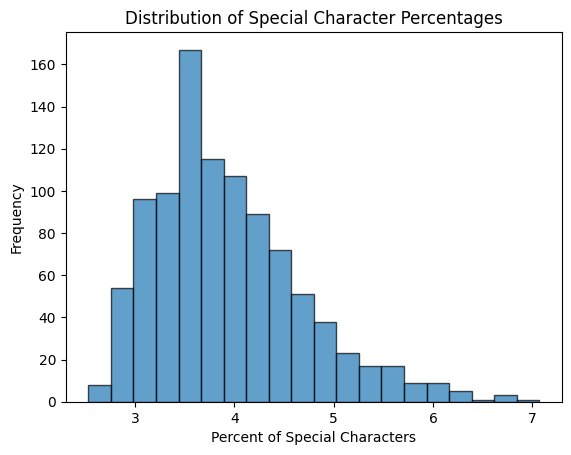

In [25]:
special_char_percentages = calculate_special_character_percentage(texts)
plot_special_character_distribution(special_char_percentages)

<br/><br/>

### Exercise 3.2

Explore if there is a correlation between the OCR quality metrics and the special character rate at the document level and at the sentence level.

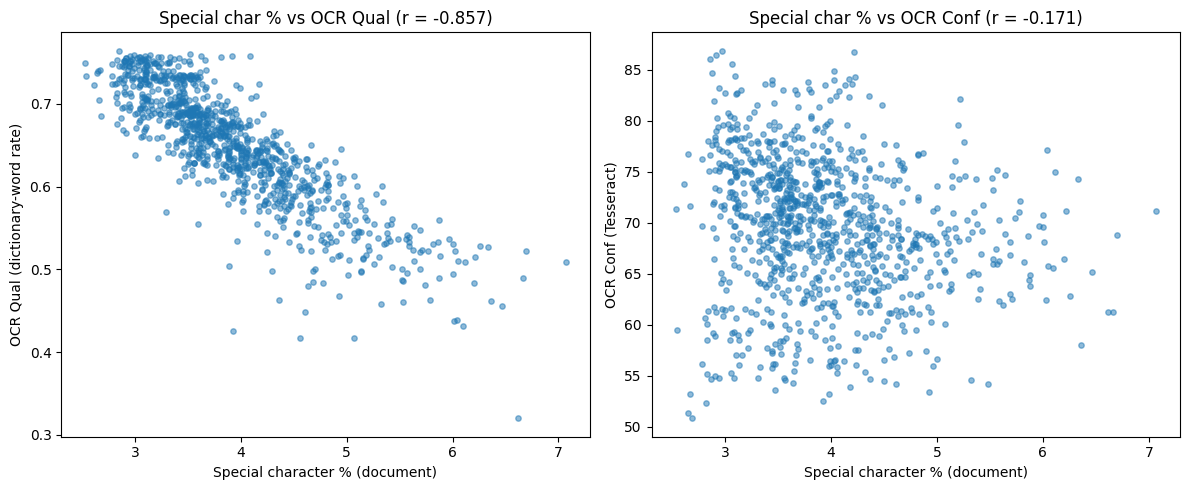

Document-level correlation:
  special_pct vs OCR Qual: r = -0.857
  special_pct vs OCR Conf: r = -0.171


In [26]:
# Get OCR confidence from xlsx files in data_text (same source as Notebook 2)
def read_xlsx_ocr_conf(folder_path: str):
    """Read xlsx files and return dict of filename -> mean OCR confidence."""
    import os
    result = {}
    for filename in os.listdir(folder_path):
        if not filename.endswith(".xlsx"):
            continue
        path = os.path.join(folder_path, filename)
        try:
            df = pd.read_excel(path, engine="openpyxl")
            if "conf" in df.columns:
                vals = df["conf"][df["conf"] > 0].values
                result[filename] = float(np.mean(vals)) if len(vals) > 0 else np.nan
            else:
                result[filename] = np.nan
        except Exception:
            result[filename] = np.nan
    return result

def calculate_ocr_quality_from_texts(texts: List):
    """OCR quality = fraction of tokens that are dictionary words (spacy vocab)."""
    nlp = spacy.load("en_core_web_sm", exclude=["parser", "ner", "lemmatizer"])
    scores = []
    for text in texts:
        doc = nlp(text[:100000])
        total = len(doc)
        if total == 0:
            scores.append(0.0)
            continue
        english = sum(1 for t in doc if t.is_alpha and t.text.lower() in nlp.vocab)
        scores.append(english / total)
    return scores

xlsx_to_conf = read_xlsx_ocr_conf(data_text)
ocr_qual_list = calculate_ocr_quality_from_texts(texts)

# Build document-level dataframe: filename (txt), special_pct, ocr_qual, ocr_conf
df_doc = pd.DataFrame({
    "filename": filenames,
    "special_pct": special_char_percentages,
    "ocr_qual": ocr_qual_list,
})
df_doc["ocr_conf"] = df_doc["filename"].apply(
    lambda f: xlsx_to_conf.get(f.replace(".txt", ".xlsx"), np.nan)
)
df_doc = df_doc.dropna(subset=["ocr_qual", "ocr_conf"])

# Correlations and scatter plots (document level)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(df_doc["special_pct"], df_doc["ocr_qual"], alpha=0.5, s=15)
axes[0].set_xlabel("Special character % (document)")
axes[0].set_ylabel("OCR Qual (dictionary-word rate)")
r_qual = df_doc["special_pct"].corr(df_doc["ocr_qual"])
axes[0].set_title(f"Special char % vs OCR Qual (r = {r_qual:.3f})")
axes[1].scatter(df_doc["special_pct"], df_doc["ocr_conf"], alpha=0.5, s=15)
axes[1].set_xlabel("Special character % (document)")
axes[1].set_ylabel("OCR Conf (Tesseract)")
r_conf = df_doc["special_pct"].corr(df_doc["ocr_conf"])
axes[1].set_title(f"Special char % vs OCR Conf (r = {r_conf:.3f})")
plt.tight_layout()
plt.show()
print("Document-level correlation:")
print(f"  special_pct vs OCR Qual: r = {r_qual:.3f}")
print(f"  special_pct vs OCR Conf: r = {r_conf:.3f}")


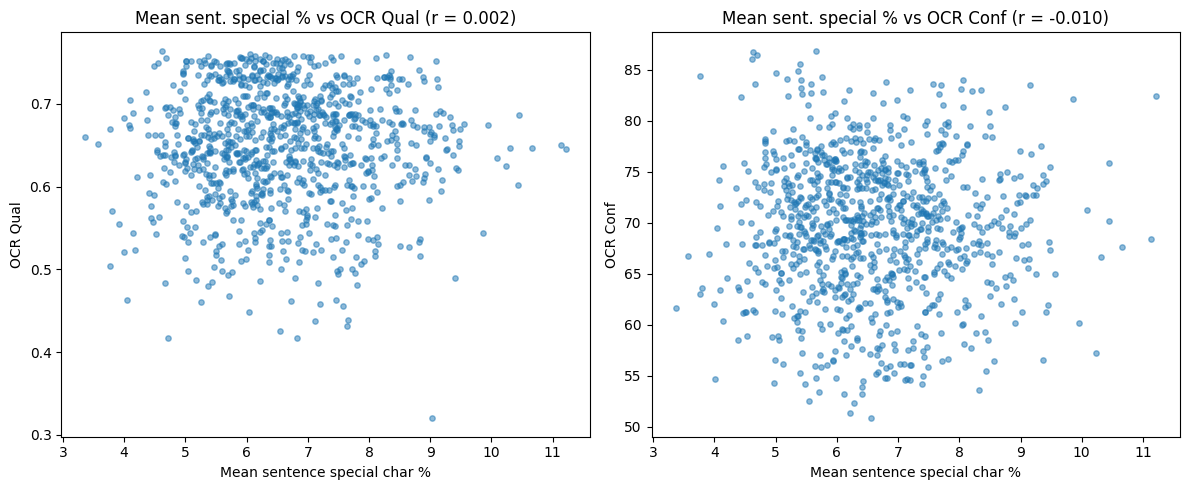

Sentence-level (mean per document) correlation:
  mean_sent_special_pct vs OCR Qual: r = 0.002
  mean_sent_special_pct vs OCR Conf: r = -0.010


In [28]:
# Per-sentence special char %, then mean per document
def special_pct(s: str) -> float:
    if not s or len(s) == 0:
        return 0.0
    total = len(s)
    special = sum(1 for c in s if not c.isalnum() and c not in "\n ")
    return 100.0 * special / total

sentences_df["sent_special_pct"] = sentences_df["sentence_text"].apply(special_pct)
mean_sent_special = sentences_df.groupby("filename")["sent_special_pct"].mean().reset_index()
mean_sent_special.columns = ["filename", "mean_sent_special_pct"]
df_sent = df_doc.merge(mean_sent_special, on="filename", how="inner")

fig2, ax2 = plt.subplots(1, 2, figsize=(12, 5))
ax2[0].scatter(df_sent["mean_sent_special_pct"], df_sent["ocr_qual"], alpha=0.5, s=15)
ax2[0].set_xlabel("Mean sentence special char %")
ax2[0].set_ylabel("OCR Qual")
r_sent_qual = df_sent["mean_sent_special_pct"].corr(df_sent["ocr_qual"])
ax2[0].set_title(f"Mean sent. special % vs OCR Qual (r = {r_sent_qual:.3f})")
ax2[1].scatter(df_sent["mean_sent_special_pct"], df_sent["ocr_conf"], alpha=0.5, s=15)
ax2[1].set_xlabel("Mean sentence special char %")
ax2[1].set_ylabel("OCR Conf")
r_sent_conf = df_sent["mean_sent_special_pct"].corr(df_sent["ocr_conf"])
ax2[1].set_title(f"Mean sent. special % vs OCR Conf (r = {r_sent_conf:.3f})")
plt.tight_layout()
plt.show()
print("Sentence-level (mean per document) correlation:")
print(f"  mean_sent_special_pct vs OCR Qual: r = {r_sent_qual:.3f}")
print(f"  mean_sent_special_pct vs OCR Conf: r = {r_sent_conf:.3f}")


<br/><br/>

### Sentence Distributions


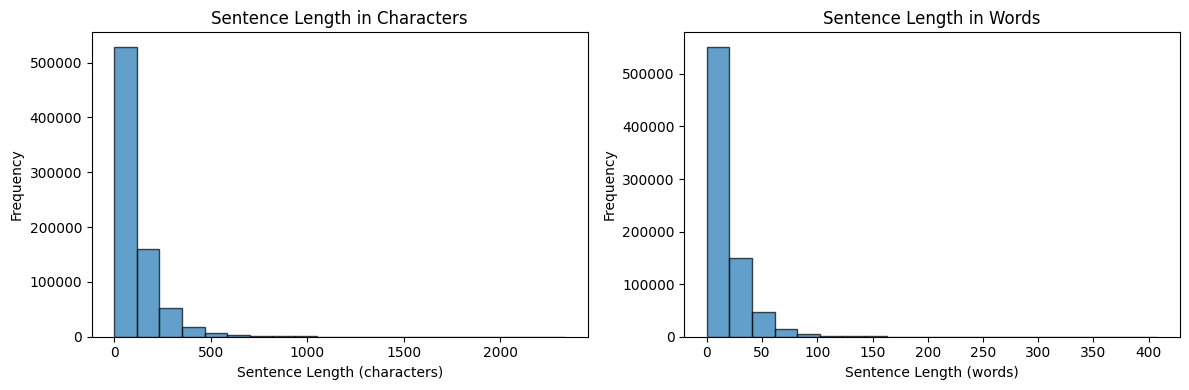

In [29]:
def plot_sentence_length_histograms(dataframe, column_name: str):
    """
    Plot side-by-side histograms of sentence lengths in characters and words for a given column in a Pandas DataFrame.

    Parameters:
    - dataframe (DataFrame): The Pandas DataFrame.
    - column_name (str): The name of the column containing sentences.

    Returns:
    None
    """
    # Calculate sentence lengths in characters and words
    dataframe['sentence_length_chars'] = dataframe[column_name].apply(lambda x: len(x))
    dataframe['sentence_length_words'] = dataframe[column_name].apply(lambda x: len(x.split()))

    # Create subplots
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Plot histogram of sentence lengths in characters
    axes[0].hist(dataframe['sentence_length_chars'], bins=20, edgecolor='black', alpha=0.7)
    axes[0].set_title('Sentence Length in Characters')
    axes[0].set_xlabel('Sentence Length (characters)')
    axes[0].set_ylabel('Frequency')

    # Plot histogram of sentence lengths in words
    axes[1].hist(dataframe['sentence_length_words'], bins=20, edgecolor='black', alpha=0.7)
    axes[1].set_title('Sentence Length in Words')
    axes[1].set_xlabel('Sentence Length (words)')
    axes[1].set_ylabel('Frequency')

    # Adjust layout
    plt.tight_layout()

    # Show the plot
    plt.show()

plot_sentence_length_histograms(sentences_df, 'sentence_text')

<br/><br/>

### Exercise 3.3

Explore if there is a correlation between the OCR quality metrics and the average sentence length across the documents.

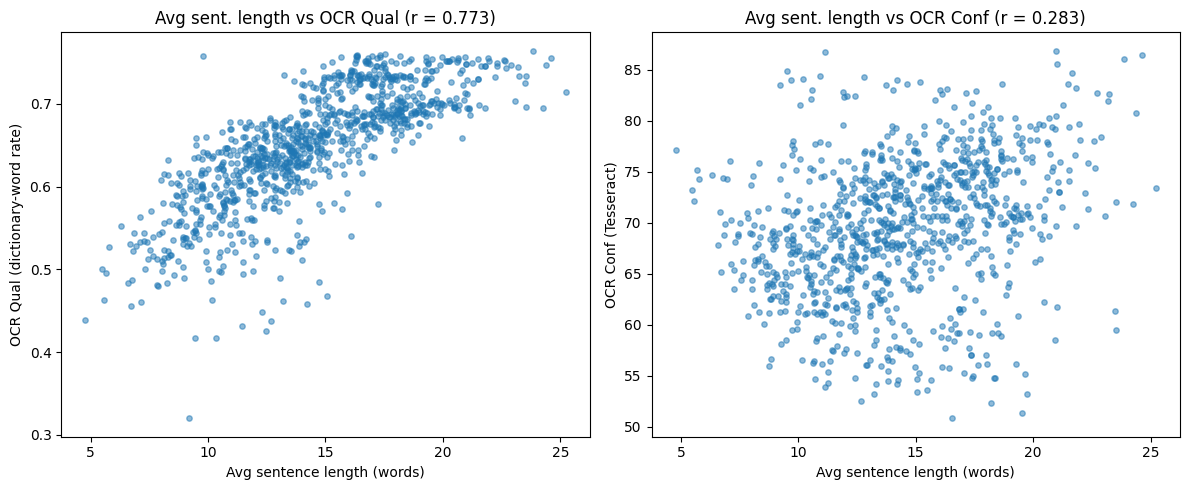

In [31]:
# Average sentence length (words) per document from sentences_df
sentences_df["sent_length_words"] = sentences_df["sentence_text"].str.split().str.len()
avg_sent_len = sentences_df.groupby("filename")["sent_length_words"].mean().reset_index()
avg_sent_len.columns = ["filename", "avg_sentence_length_words"]
df_len = df_doc[["filename", "ocr_qual", "ocr_conf"]].merge(avg_sent_len, on="filename", how="inner")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(df_len["avg_sentence_length_words"], df_len["ocr_qual"], alpha=0.5, s=15)
axes[0].set_xlabel("Avg sentence length (words)")
axes[0].set_ylabel("OCR Qual (dictionary-word rate)")
r_qual = df_len["avg_sentence_length_words"].corr(df_len["ocr_qual"])
axes[0].set_title(f"Avg sent. length vs OCR Qual (r = {r_qual:.3f})")
axes[1].scatter(df_len["avg_sentence_length_words"], df_len["ocr_conf"], alpha=0.5, s=15)
axes[1].set_xlabel("Avg sentence length (words)")
axes[1].set_ylabel("OCR Conf (Tesseract)")
r_conf = df_len["avg_sentence_length_words"].corr(df_len["ocr_conf"])
axes[1].set_title(f"Avg sent. length vs OCR Conf (r = {r_conf:.3f})")
plt.tight_layout()
plt.show()

In [32]:
print("Correlation: average sentence length (words) vs OCR metrics")
print(f"  avg_sentence_length vs OCR Qual: r = {r_qual:.3f}")
print(f"  avg_sentence_length vs OCR Conf: r = {r_conf:.3f}")

Correlation: average sentence length (words) vs OCR metrics
  avg_sentence_length vs OCR Qual: r = 0.773
  avg_sentence_length vs OCR Conf: r = 0.283


<br/><br/>

### Exercise 3.4

Explore if there is a correlation between the OCR quality metrics and the date of the documents.

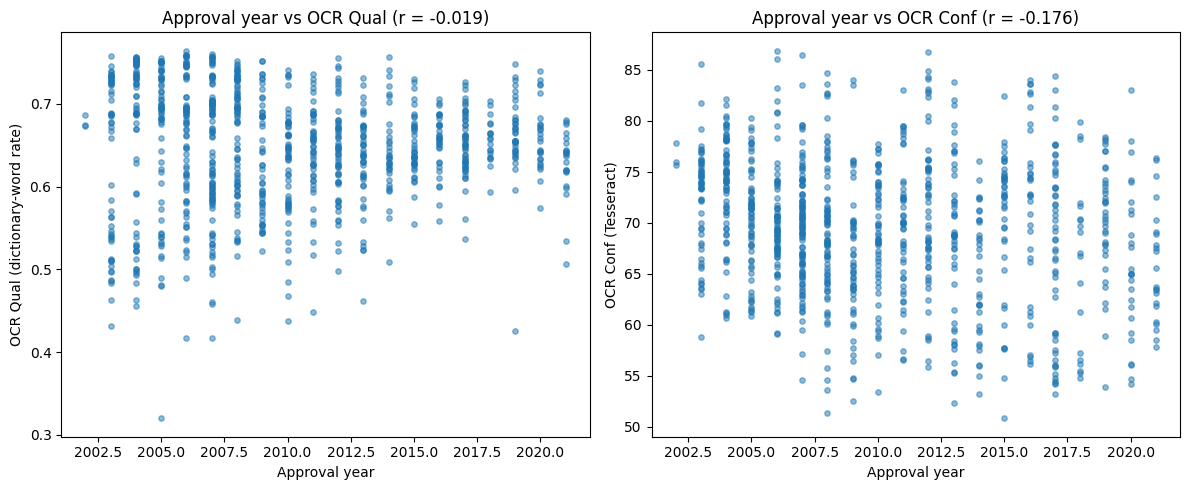

In [39]:
# Map filename (e.g. "000037ZS.pdf.txt") to URL ID for merging with contracts CSV
df_date = df_doc[["filename", "ocr_qual", "ocr_conf"]].copy()
df_date["url_id"] = df_date["filename"].apply(lambda f: f.split(".pdf")[0])

contracts_path = os.path.join(datum, "Contracts_20231227.csv")
if os.path.exists(contracts_path):
    contracts = pd.read_csv(contracts_path, low_memory=False)
    contracts["URL ID"] = contracts["Contract PDF"].apply(
        lambda x: x.split("/")[-1].split("=")[-1] if isinstance(x, str) else ""
    )
    contracts_sub = contracts[["URL ID", "Approval Date"]].drop_duplicates("URL ID")
    df_date = df_date.merge(contracts_sub, left_on="url_id", right_on="URL ID", how="left")
    df_date["approval_date"] = pd.to_datetime(df_date["Approval Date"], errors="coerce")
    df_date["approval_year"] = df_date["approval_date"].dt.year
else:
    df_date["approval_year"] = np.nan

df_with_date = df_date.dropna(subset=["approval_year"])
if len(df_with_date) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].scatter(df_with_date["approval_year"], df_with_date["ocr_qual"], alpha=0.5, s=15)
    axes[0].set_xlabel("Approval year")
    axes[0].set_ylabel("OCR Qual (dictionary-word rate)")
    r_qual = df_with_date["approval_year"].corr(df_with_date["ocr_qual"])
    axes[0].set_title(f"Approval year vs OCR Qual (r = {r_qual:.3f})")
    axes[1].scatter(df_with_date["approval_year"], df_with_date["ocr_conf"], alpha=0.5, s=15)
    axes[1].set_xlabel("Approval year")
    axes[1].set_ylabel("OCR Conf (Tesseract)")
    r_conf = df_with_date["approval_year"].corr(df_with_date["ocr_conf"])
    axes[1].set_title(f"Approval year vs OCR Conf (r = {r_conf:.3f})")
    plt.tight_layout()
    plt.show()
else:
    print("No documents with approval date found. Ensure Contracts_20231227.csv exists and URL IDs match.")

In [40]:
print("Correlation: document approval year vs OCR metrics")
print(f"  approval_year vs OCR Qual: r = {r_qual:.3f}")
print(f"  approval_year vs OCR Conf: r = {r_conf:.3f}")
print(f"  (Documents with date: {len(df_with_date)} of {len(df_date)})")

Correlation: document approval year vs OCR metrics
  approval_year vs OCR Qual: r = -0.019
  approval_year vs OCR Conf: r = -0.176
  (Documents with date: 981 of 981)


<br/>

### Visualization: Word Cloud

Although it is highly qualitative, it can sometimes be helpful to visualize the most common words in a corpus.

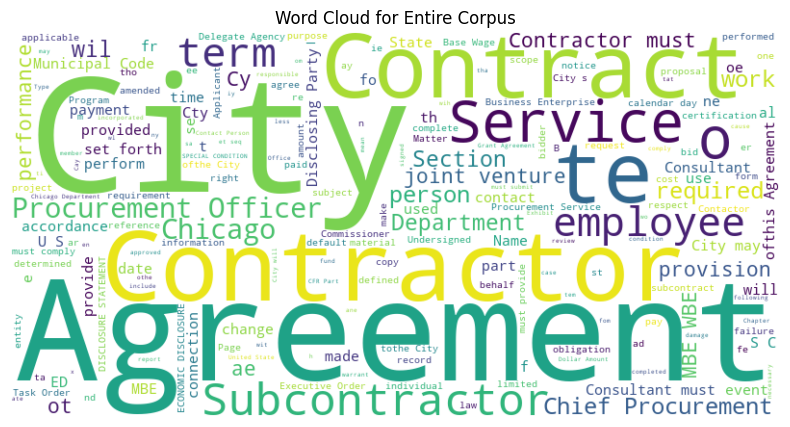

In [41]:
def generate_word_cloud(dataframe, column_name: str, title_string: str = 'Word Cloud for Entire Corpus'):
    """
    Generate and display a word cloud for a given column in a Pandas DataFrame.

    Parameters:
    - dataframe (DataFrame): The Pandas DataFrame.
    - column_name (str): The name of the column containing sentences.

    Returns:
    None
    """
    # Combine all sentences into a single string
    all_text = ' '.join(dataframe[column_name])

    # Generate word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

    # Plot the word cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title_string)
    plt.show()

generate_word_cloud(sentences_df, 'sentence_text')

<br/><br/>

### Exercise 3.5

Generate additional word clouds for each of these subsets:
1. Master agreements
2. RFPs
3. Bids

Are there patterns or commonalities?

(*Hint*: Use the original CSV from notebook one to subset the data by filename)

In [47]:
def url_id_to_txt_filename(uid):
    return (uid + ".pdf.txt") if uid else None

contracts_path = os.path.join(datum, "Contracts_20231227.csv")
if not os.path.exists(contracts_path):
    print("Contracts_20231227.csv not found. Cannot subset by type.")
else:
    contracts = pd.read_csv(contracts_path, low_memory=False)
    contracts["URL ID"] = contracts["Contract PDF"].apply(
        lambda x: x.split("/")[-1].split("=")[-1] if isinstance(x, str) and str(x).strip() else ""
    )

subsets = {
    "Master agreements": contracts[contracts["Procurement Type"].astype(str).str.strip().str.upper() == "MASTER AGREEMENT"]["URL ID"].dropna().unique(),
    "RFPs": contracts[contracts["Procurement Type"].astype(str).str.strip().str.upper() == "RFP"]["URL ID"].dropna().unique(),
    "Bids": contracts[contracts["Procurement Type"].astype(str).str.strip().str.upper() == "BID"]["URL ID"].dropna().unique(),
}

Master agreements: No matching documents in corpus (skipping word cloud).
RFPs: 256817 sentences from 296 documents


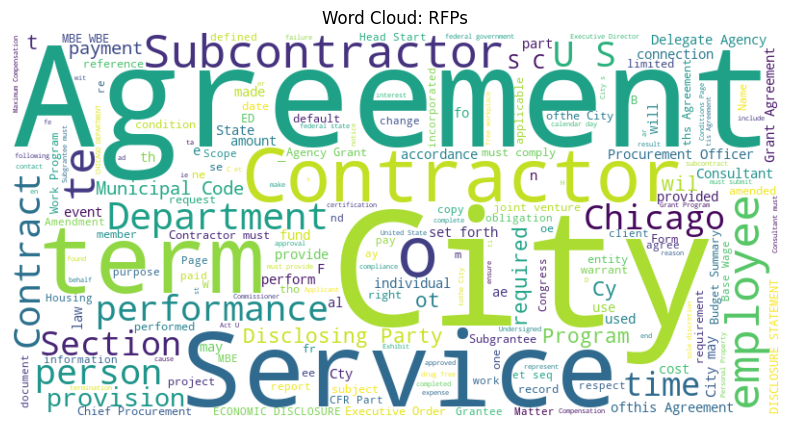

Bids: 270534 sentences from 487 documents


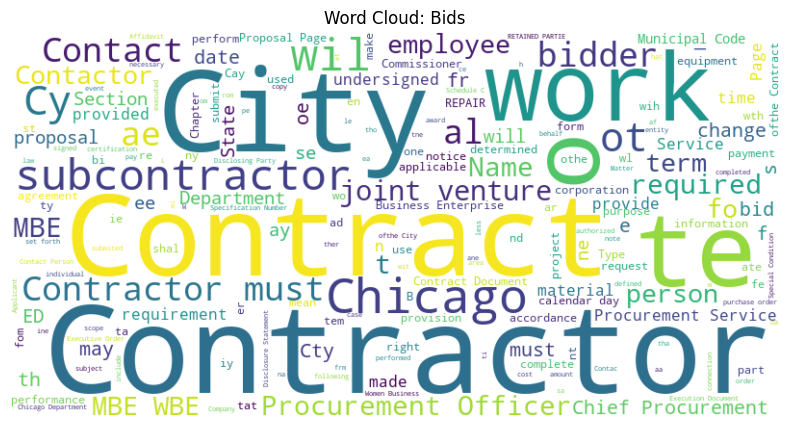

In [48]:
for label, url_ids in subsets.items():
    url_ids = [u for u in url_ids if u]
    filenames_sub = [url_id_to_txt_filename(uid) for uid in url_ids]
    filenames_sub = [f for f in filenames_sub if f]
    df_sub = sentences_df[sentences_df["filename"].isin(filenames_sub)]
    if len(df_sub) == 0:
        print(f"{label}: No matching documents in corpus (skipping word cloud).")
            print("  (This corpus was built from BID/RFP/RFQ samples only; no Master agreement PDFs are present.)")
        continue
    print(f"{label}: {len(df_sub)} sentences from {df_sub['filename'].nunique()} documents")
    generate_word_cloud(df_sub, "sentence_text", title_string=f"Word Cloud: {label}")

<br/><br/><br/>